In [1]:

import calendar
import os
import pandas as pd
import xarray as xr
import numpy as np
import cdsapi
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
EXCEL_FILE = "Projectfile_test_Kaushik.xlsx"
START_DATE = "1995-01-01"
END_DATE   = "2026-03-31"
DAILY_DIR  = Path("/data01/FDS/muduchuru/Atmos/ERA5-Land")   # per-year NetCDFs
OUT_DIR    = Path("/data01/FDS/muduchuru/Atmos/ERA5-Land/raw")
FINAL_NC   = OUT_DIR / "ERA5_Land_1995-01-01_2026-03-31_daily_Nigeria.nc"

DAILY_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# 3-hourly timesteps (8 per day)
TIMES_3H = ["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00"]
HOURLY_TIMES = [f"{h:02d}:00" for h in range(24)]
# ── One CDS variable per download request ────────────────────────────────────
# (cds_variable, short_name, agg_methods, is_accumulated, times)
#
# Accumulated vars  → download only "00:00" UTC (holds full 24-h total)
#                     value is used directly; no deaccumulation needed.
# Instantaneous vars → download all 3-hourly steps; resample to daily stats.
VAR_GROUPS = [
    # ("2m_temperature",                   "t2m",   ["mean", "min", "max"], False, TIMES_3H),
    # ("2m_dewpoint_temperature",           "d2m",   ["mean"],               False, TIMES_3H),
    # ("surface_solar_radiation_downwards", "ssrd",  ["sum"],                True,  ["00:00"]),
    # ("10m_u_component_of_wind",           "u10",   ["mean"],               False, TIMES_3H),
    # ("10m_v_component_of_wind",           "v10",   ["mean"],               False, TIMES_3H),
    # ("volumetric_soil_water_layer_1",     "swvl1", ["mean"],               False, TIMES_3H),
    # ("soil_temperature_level_1",          "stl1",  ["mean"],               False, TIMES_3H),
    # ("total_precipitation",              "tp",    ["sum"],                True,  ["00:00"]),
    # ("potential_evaporation",            "pev",   ["sum"],                True,  ["00:00"]),
    ("surface_solar_radiation_downwards", "ssrd", ["sum"], True, HOURLY_TIMES),
    ("total_precipitation",              "tp",   ["sum"], True, HOURLY_TIMES),
    ("potential_evaporation",            "pev",  ["sum"], True, HOURLY_TIMES),
]

# ============================================================
# READ POINTS  (x = lon, y = lat)
# ============================================================
df_proj = pd.read_excel(EXCEL_FILE)
points = (
    df_proj[["x", "y"]]
    .drop_duplicates()
    .rename(columns={"x": "lon", "y": "lat"})
    .reset_index(drop=True)
)
print(f"Unique points: {len(points)}")
print(points.head())

# ── Bounding box [N, W, S, E] ─────────────────────────────────────────────────
buf  = 0.5
area = [
    round(points["lat"].max() + buf, 2),
    round(points["lon"].min() - buf, 2),
    round(points["lat"].min() - buf, 2),
    round(points["lon"].max() + buf, 2),
]
print(f"Bounding box [N, W, S, E]: {area}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def magnus_rh(t_k, td_k):
    t  = t_k  - 273.15
    td = td_k - 273.15
    return 100.0 * np.exp((17.625 * td) / (243.04 + td)) / \
                   np.exp((17.625 * t ) / (243.04 + t ))


date_range  = pd.date_range(START_DATE, END_DATE, freq="YS")   # one entry per year


all_years   = [d.year for d in date_range]
print(f"Years to process: {all_years[0]} – {all_years[-1]}")

Unique points: 7340
    lon   lat
0  6.15  4.35
1  6.35  4.35
2  6.45  4.35
3  6.55  4.35
4  5.85  4.45
Bounding box [N, W, S, E]: [14.35, 2.25, 3.85, 15.15]
Years to process: 1995 – 2026


In [ ]:
import calendar
import concurrent.futures
import pandas as pd
import cdsapi

# ── CELL 2: FETCH — download raw 3-hourly / 00:00-UTC files from CDS ─────────

c = cdsapi.Client()


def download_single_task(task):
    """Worker function to process a single variable-month download."""
    year, month, days, cds_var, short_name, times, var_nc = task

    if var_nc.exists():
        print(f"   {year}-{month:02d} [{short_name}]: cached.")
        return f"{year}-{month:02d} [{short_name}]: Already cached."

    print(f"   {year}-{month:02d} [{short_name}]: starting download...\n", end="", flush=True)
    
    try:
        c.retrieve(
            "reanalysis-era5-land",
            {
                "variable": [cds_var],
                "year": str(year),
                "month": f"{month:02d}",
                "day": days,
                "time": times,
                "area": area,  # Assumes 'area' is defined globally
                "download_format": "unarchived",
                "format": "netcdf",
            },
            str(var_nc),
        )
        return f"{year}-{month:02d} [{short_name}]: download done."
    except Exception as e:
        return f"{year}-{month:02d} [{short_name}]: FAILED with error: {e}"


# 1. Build the list of tasks that actually need to be downloaded
download_tasks = []

for year in all_years:
    yr_nc = DAILY_DIR / f"ERA5Land_daily_{year}.nc"
    if yr_nc.exists():
        print(f"{year}: annual file already exists, skipping fetch.")
        continue

    for month in range(1, 13):
        end_of_month = pd.Timestamp(
            year=year,
            month=month,
            day=calendar.monthrange(year, month)[1],
        )
        if pd.Timestamp(START_DATE) > end_of_month:
            continue
        if pd.Timestamp(END_DATE) < pd.Timestamp(f"{year}-{month:02d}-01"):
            break

        n_days = calendar.monthrange(year, month)[1]
        days = [f"{d:02d}" for d in range(1, n_days + 1)]

        for cds_var, short_name, agg_methods, is_accum, times in VAR_GROUPS:
            var_nc = DAILY_DIR / f"era5land_{short_name}_{year}_{month:02d}.nc"
            
            # Queue the metadata for the worker pool
            download_tasks.append(
                (year, month, days, cds_var, short_name, times, var_nc)
            )

# 2. Run the tasks in parallel using 4 workers
MAX_WORKERS = 4
print(f"\nStarting parallel downloads with {MAX_WORKERS} workers for {len(download_tasks)} potential tasks...\n")

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Map the download function over our tasks list
    results = executor.map(download_single_task, download_tasks)
    
    # Consume results to ensure errors (if any) are raised/printed
    for result in results:
        if "done" in result or "FAILED" in result:
            print(result)

print("\nFetch complete.")


Starting parallel downloads with 4 workers for 1125 potential tasks...

   1995-01 [ssrd]: cached.
   1995-01 [tp]: starting download...
   1995-01 [pev]: starting download...
   1995-02 [ssrd]: starting download...
   1995-02 [tp]: starting download...


2026-06-01 20:49:31,425 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-01 20:49:31,425 INFO Request ID is d24c09a7-1fac-4e82-bf5e-e1d74c65673b
2026-06-01 20:49:31,443 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datas

df1ff054be7003a245e4b18b97b50684.nc:   0%|          | 0.00/4.92M [00:00<?, ?B/s]

   1995-02 [pev]: starting download...


2026-06-01 20:52:34,748 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-01 20:52:34,749 INFO Request ID is 3613f6e5-9410-4ba9-8cc1-559cf8c5a393
2026-06-01 20:52:35,511 INFO status has been updated to accepted
2026-06-01 20:53:55,656 INFO status has been updated to successful


...

   1995-03 [ssrd]: starting download...


2026-06-01 20:54:00,863 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-01 20:54:00,864 INFO Request ID is 05401da0-1c5d-46f4-b08d-5b51ea6c1802
2026-06-01 20:54:02,170 INFO status has been updated to accepted
2026-06-01 20:55:52,907 INFO status has been updated to successful


c03f0e24d6954a50d86a673f5e920dd7.nc:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

   1995-03 [tp]: starting download...


2026-06-01 20:55:55,750 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-01 20:55:55,750 INFO Request ID is 4ae919fd-7ded-45b9-9407-8042c485d416
2026-06-01 20:55:55,828 INFO status has been updated to accepted
2026-06-01 20:56:54,163 INFO status has been updated to running


In [ ]:

# ── CELL 3: LOAD — aggregate to daily, derive CF vars, write annual NetCDFs ──

from dask.distributed import Client, LocalCluster

n_workers = min(os.cpu_count(), 8)
cluster   = LocalCluster(n_workers=n_workers, threads_per_worker=2, memory_limit="4GB")
client    = Client(cluster)
print(f"Dask dashboard : {client.dashboard_link}")

year_files = []

for year in all_years:
    yr_nc = DAILY_DIR / f"ERA5Land_daily_{year}.nc"
    year_files.append(yr_nc)

    if yr_nc.exists():
        print(f"{year}: already done, skipping.")
        continue

    month_ds = []

    for month in range(1, 13):
        end_of_month = pd.Timestamp(year=year, month=month,
                                    day=calendar.monthrange(year, month)[1])
        if pd.Timestamp(START_DATE) > end_of_month:
            continue
        if pd.Timestamp(END_DATE) < pd.Timestamp(f"{year}-{month:02d}-01"):
            break

        agg_datasets = []

        for cds_var, short_name, agg_methods, is_accum, times in VAR_GROUPS:
            var_nc = DAILY_DIR / f"era5land_{short_name}_{year}_{month:02d}.nc"

            ds_v = xr.open_dataset(var_nc)
            if "valid_time" in ds_v.dims:
                ds_v = ds_v.rename({"valid_time": "time"})

            sv     = list(ds_v.data_vars)[0]
            da     = ds_v[sv]
            agg_ds = xr.Dataset()

            if is_accum:
                # 00:00 UTC snapshot = full 24-h accumulation → one value per day
                agg_ds[f"{short_name}_sum"] = (
                    da.squeeze("time", drop=True)
                    if da.sizes["time"] == 1
                    else da.isel(time=0)
                )
            else:
                for agg in agg_methods:
                    out_name = f"{short_name}_{agg}"
                    if agg == "mean":
                        agg_ds[out_name] = da.resample(time="1D").mean()
                    elif agg == "min":
                        agg_ds[out_name] = da.resample(time="1D").min()
                    elif agg == "max":
                        agg_ds[out_name] = da.resample(time="1D").max()

            ds_v.close()
            agg_datasets.append(agg_ds)

            # Remove raw file immediately to free disk
            if var_nc.exists():
                var_nc.unlink()

        ds_m = xr.merge(agg_datasets)
        month_ds.append(ds_m)

    if not month_ds:
        continue

    # ── Merge months → derive CF variables → write annual NetCDF ─────────────
    ds_yr = xr.concat(month_ds, dim="time")

    ds_out = xr.Dataset({
        "tas":     ds_yr["t2m_mean"]  - 273.15,
        "tasmin":  ds_yr["t2m_min"]   - 273.15,
        "tasmax":  ds_yr["t2m_max"]   - 273.15,
        "pr":      ds_yr["tp_sum"]    * 1000.0,    # m → mm/day
        "rsds":    ds_yr["ssrd_sum"]  / 86400.0,   # J m⁻²/day → W m⁻²
        "pet":     ds_yr["pev_sum"]   * -1000.0,   # m → mm/day, flip sign
        "swvl1":   ds_yr["swvl1_mean"],
        "stl1":    ds_yr["stl1_mean"] - 273.15,
        "hurs":    magnus_rh(ds_yr["t2m_mean"], ds_yr["d2m_mean"]),
        "sfcWind": np.sqrt(ds_yr["u10_mean"]**2 + ds_yr["v10_mean"]**2),
    })

    attrs = {
        "tas":     ("degC",   "Daily mean 2 m temperature"),
        "tasmin":  ("degC",   "Daily minimum 2 m temperature"),
        "tasmax":  ("degC",   "Daily maximum 2 m temperature"),
        "pr":      ("mm/day", "Total precipitation"),
        "rsds":    ("W/m2",   "Surface downwelling shortwave radiation"),
        "pet":     ("mm/day", "Potential evapotranspiration"),
        "swvl1":   ("m3/m3",  "Volumetric soil water layer 1"),
        "stl1":    ("degC",   "Soil temperature layer 1"),
        "hurs":    ("%",      "Relative humidity"),
        "sfcWind": ("m/s",    "Near-surface wind speed"),
    }
    for var, (unit, lname) in attrs.items():
        ds_out[var].attrs = {"units": unit, "long_name": lname}

    ds_out = ds_out.chunk({"time": 365,
                            "latitude":  ds_out.sizes["latitude"],
                            "longitude": ds_out.sizes["longitude"]})
    ds_out.to_netcdf(yr_nc, compute=True)
    print(f"{year}: saved → {yr_nc}")

client.close()
cluster.close()
print("\nAll years processed.")

# ── Extract points + merge all years into one final NetCDF ───────────────────
print(f"Merging {len(year_files)} annual files and extracting points …")
ds_all = xr.open_mfdataset([f for f in year_files if f.exists()], combine="by_coords")
ds_all = ds_all.sel(time=slice(START_DATE, END_DATE))

lats_da = xr.DataArray(points["lat"].values, dims="points")
lons_da = xr.DataArray(points["lon"].values, dims="points")
ds_pts  = ds_all.sel(latitude=lats_da, longitude=lons_da, method="nearest")
ds_pts  = ds_pts.assign_coords(
    input_lat=("points", points["lat"].values),
    input_lon=("points", points["lon"].values),
)

ds_pts.to_netcdf(FINAL_NC)
ds_all.close()
print(f"Final file saved → {FINAL_NC}")


In [2]:
import json
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import xarray as xr


# ------------------------------------------------------------------
# CF -> SIMPLACE names
# ------------------------------------------------------------------
CF_TO_SIMPLACE = {
    "tas": "TempMean",
    "tasmin": "TempMin",
    "tasmax": "TempMax",
    "pr": "Precipitation",
    "rsds": "Radiation",
    "pet": "ETpot",
    "hurs": "RelHum",
    "sfcWind": "Windspeed",
    "swvl1": "SoilWaterL1",
    "stl1": "SoilTempL1",
}


# ------------------------------------------------------------------
# Unit conversions
# ------------------------------------------------------------------
_W2 = np.log(2.0 / 0.01) / np.log(10.0 / 0.01)

UNIT_CONVERSIONS = {
    "Radiation": lambda x: x * 86.4,
    "Windspeed": lambda x: x * _W2,
}


UNITS = {
    "TempMean": "°C",
    "TempMin": "°C",
    "TempMax": "°C",
    "Precipitation": "mm",
    "Radiation": "kJ m-2",
    "ETpot": "mm day-1",
    "RelHum": "%",
    "Windspeed": "m s-1",
    "SoilWaterL1": "m3/m3",
    "SoilTempL1": "°C",
}


# ------------------------------------------------------------------
# Globals used by workers
# ------------------------------------------------------------------
DS = None
DATES = None
LAT_TO_ROW = None
LON_TO_COL = None
RENAME_MAP = None
SIMPLACE_VARS = None
BASE_DIR = None


# ------------------------------------------------------------------
# Worker
# ------------------------------------------------------------------
def _write_point(point):

    lat = float(DS.latitude.values[point])
    lon = float(DS.longitude.values[point])

    row = LAT_TO_ROW[lat]
    col = LON_TO_COL[lon]

    df = pd.DataFrame({
        "Date": DATES
    })

    for cf_name, sim_name in RENAME_MAP.items():

        values = DS[cf_name].isel(points=point).values

        if sim_name in UNIT_CONVERSIONS:
            values = UNIT_CONVERSIONS[sim_name](values)

        df[sim_name] = values

    out_dir = BASE_DIR / str(col)
    out_dir.mkdir(parents=True, exist_ok=True)

    rel_file = f"{col}/ERA5Land_Daily_C{col}R{row}.csv"
    out_file = BASE_DIR / rel_file

    df.to_csv(
        out_file,
        sep="\t",
        index=False,
        float_format="%.4f"
    )

    return {
        "lat": round(lat, 6),
        "lon": round(lon, 6),
        "row": row,
        "col": col,
        "file": rel_file,
    }


# ------------------------------------------------------------------
# Main function
# ------------------------------------------------------------------
def nc_to_simplace(
    nc_path,
    out_dir="simplace_output",
    max_workers=None
):

    global DS
    global DATES
    global LAT_TO_ROW
    global LON_TO_COL
    global RENAME_MAP
    global SIMPLACE_VARS
    global BASE_DIR

    if max_workers is None:
        max_workers = min(32, (os.cpu_count() or 4) + 4)

    BASE_DIR = Path(out_dir)
    BASE_DIR.mkdir(parents=True, exist_ok=True)

    print("Opening dataset...")

    DS = xr.open_dataset(
        nc_path,
        chunks={"time": 365}
    )

    n_points = DS.sizes["points"]
    n_times = DS.sizes["time"]

    print(f"Points : {n_points}")
    print(f"Times  : {n_times}")

    # --------------------------------------------------------------
    # Determine available variables
    # --------------------------------------------------------------
    RENAME_MAP = {
        cf: sim
        for cf, sim in CF_TO_SIMPLACE.items()
        if cf in DS.data_vars
    }

    SIMPLACE_VARS = list(RENAME_MAP.values())

    # --------------------------------------------------------------
    # Dates
    # --------------------------------------------------------------
    DATES = pd.to_datetime(
        DS.time.values
    ).date

    # --------------------------------------------------------------
    # Unique grid coordinates
    # --------------------------------------------------------------
    unique_lats = np.sort(
        np.unique(DS.latitude.values)
    )[::-1]

    unique_lons = np.sort(
        np.unique(DS.longitude.values)
    )

    LAT_TO_ROW = {
        float(v): i
        for i, v in enumerate(unique_lats)
    }

    LON_TO_COL = {
        float(v): i
        for i, v in enumerate(unique_lons)
    }

    print(
        f"Grid reconstructed: "
        f"{len(unique_lats)} rows × "
        f"{len(unique_lons)} cols"
    )

    # --------------------------------------------------------------
    # Write CSVs
    # --------------------------------------------------------------
    mapping_entries = []

    print(
        f"Writing {n_points} files "
        f"using {max_workers} threads..."
    )

    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:

        futures = {
            executor.submit(_write_point, point): point
            for point in range(n_points)
        }

        completed = 0

        for future in as_completed(futures):

            mapping_entries.append(
                future.result()
            )

            completed += 1

            if completed % 100 == 0:
                print(
                    f"{completed}/{n_points} written"
                )

    # --------------------------------------------------------------
    # Mapping JSON
    # --------------------------------------------------------------
    mapping_entries.sort(
        key=lambda x: (x["row"], x["col"])
    )

    mapping = {
        "source_nc": str(
            Path(nc_path).resolve()
        ),
        "units": {
            v: UNITS.get(v, "")
            for v in SIMPLACE_VARS
        },
        "grid": {
            "n_rows": len(unique_lats),
            "n_cols": len(unique_lons),
            "lat_min": float(unique_lats.min()),
            "lat_max": float(unique_lats.max()),
            "lon_min": float(unique_lons.min()),
            "lon_max": float(unique_lons.max()),
        },
        "mapping": mapping_entries,
    }

    json_file = BASE_DIR / "latlon_to_colrow.json"

    with open(json_file, "w") as f:
        json.dump(mapping, f, indent=2)

    DS.close()

    print()
    print("Finished")
    print(f"CSV output : {BASE_DIR.resolve()}")
    print(f"Mapping    : {json_file}")

    return str(BASE_DIR.resolve())


# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
if __name__ == "__main__":

    nc_to_simplace(
        nc_path="/data01/FDS/muduchuru/Atmos/ERA5-Land/raw/ERA5_Land_1995-01-01_2026-03-31_daily_Nigeria.nc",
        out_dir="simplace_output",
        max_workers=32,
    )

Opening dataset...


/home/muduchuru/miniforge3/envs/sdba/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'radolan' loading failed:
module 'xarray' has no attribute 'register_datatree_accessor'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Points : 7340
Times  : 11413
Grid reconstructed: 96 rows × 120 cols
Writing 7340 files using 32 threads...
100/7340 written
200/7340 written
300/7340 written
400/7340 written
500/7340 written
600/7340 written
700/7340 written
800/7340 written
900/7340 written
1000/7340 written
1100/7340 written
1200/7340 written
1300/7340 written
1400/7340 written
1500/7340 written
1600/7340 written
1700/7340 written
1800/7340 written
1900/7340 written
2000/7340 written
2100/7340 written
2200/7340 written
2300/7340 written
2400/7340 written
2500/7340 written
2600/7340 written
2700/7340 written
2800/7340 written
2900/7340 written
3000/7340 written
3100/7340 written
3200/7340 written
3300/7340 written
3400/7340 written
3500/7340 written
3600/7340 written
3700/7340 written
3800/7340 written
3900/7340 written
4000/7340 written
4100/7340 written
4200/7340 written
4300/7340 written
4400/7340 written
4500/7340 written
4600/7340 written
4700/7340 written
4800/7340 written
4900/7340 written
5000/7340 written
51

In [10]:
import xarray as xr
nc_path="/data01/FDS/muduchuru/Atmos/ERA5-Land/ERA5Land_daily_1995.nc"
ds = xr.open_dataset(nc_path, chunks={"time": 365})

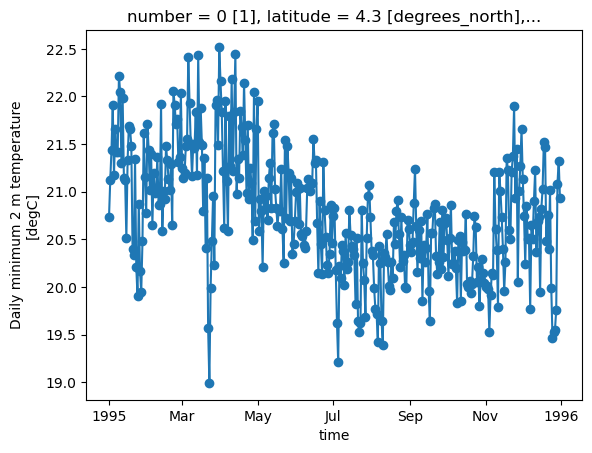

In [20]:
ds['tasmin'].isel(latitude=100,longitude=100).plot(marker='o')

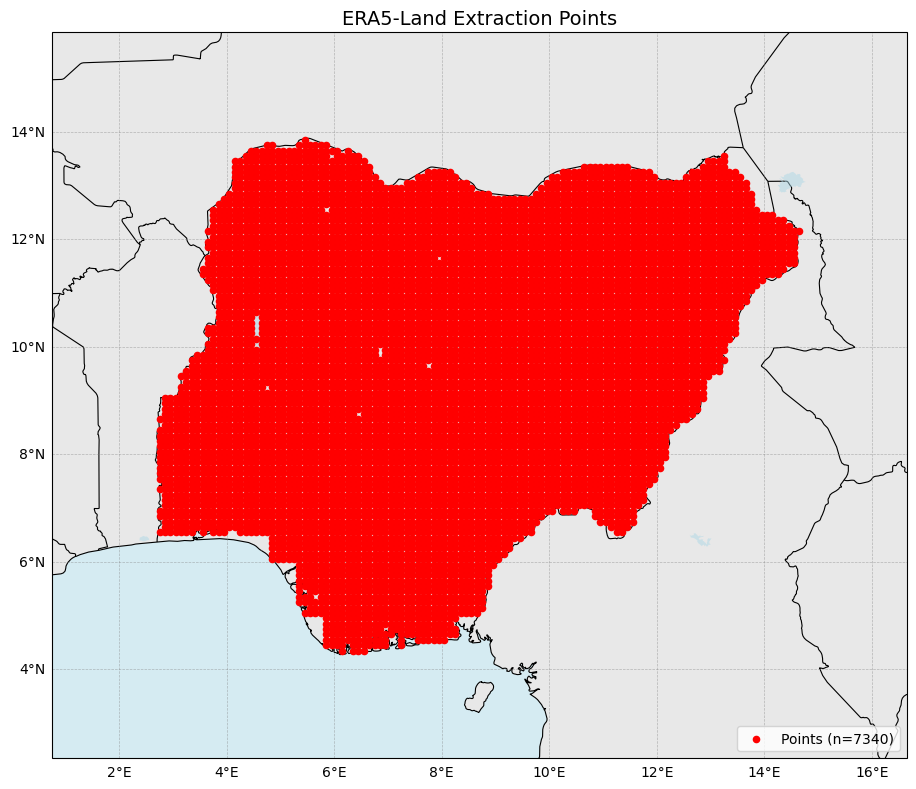

Map saved to extraction_points_map.png


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Add country borders and natural features
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.5)
ax.add_feature(cfeature.LAKES, facecolor="lightblue", alpha=0.5)

# Plot the unique extraction points
ax.scatter(
    points["lon"],
    points["lat"],
    transform=ccrs.PlateCarree(),
    color="red",
    s=20,
    zorder=5,
    label=f"Points (n={len(points)})",
)

# Auto-set extent with a small buffer
lon_min, lon_max = points["lon"].min(), points["lon"].max()
lat_min, lat_max = points["lat"].min(), points["lat"].max()
buf = 2.0
ax.set_extent(
    [lon_min - buf, lon_max + buf, lat_min - buf, lat_max + buf],
    crs=ccrs.PlateCarree(),
)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("ERA5-Land Extraction Points", fontsize=14)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("extraction_points_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved to extraction_points_map.png")
